In [2]:
#Pull data on LCV and SCV portfolios
import pandas_datareader.data as web
ff  = web.DataReader("F-F_Research_Data_Factors", "famafrench", start="1926")[0]
df  = (web.DataReader("6_Portfolios_2x3", "famafrench", start="1926")[0][["BIG HiBM", "SMALL HiBM"]])/100
mkt = (ff["Mkt-RF"] + ff["RF"])/100

In [3]:
#compute value spread as the mean of the log of large cap value/large cap growth and the log of small cap value/small cap growth
import numpy as np, pandas as pd

bm = pd.read_csv("/Users/anton/Desktop/6_Portfolios_2x3 3.csv", skiprows=5050, nrows=1202, index_col=0)

large_spread = np.log(bm["BIG HiBM"] / bm["BIG LoBM"])
small_spread = np.log(bm["SMALL HiBM"] / bm["SMALL LoBM"])
spread=(large_spread + small_spread)/2

In [4]:
m  = spread.rolling(60).mean()
sd = spread.rolling(60).std()
z  = (spread - m) / sd

signal = (z > 2).shift(1, fill_value=False)   # lag one month: decide on t-1, hold in t
tilt   = signal.astype(int).rolling(60, min_periods=1).max() == 1   # stay tilted 60 months after each signal
tilt


192607    False
192608    False
192609    False
192610    False
192611    False
          ...  
202604     True
202605     True
202606     True
202607     True
202608     True
Length: 1202, dtype: bool

<Axes: title={'center': 'Growth of $1'}, xlabel='Date'>

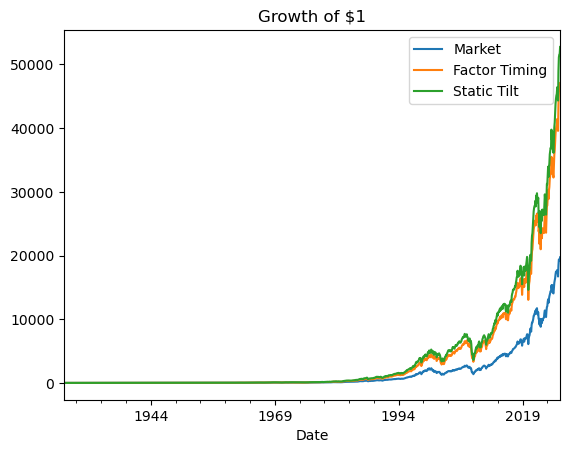

In [5]:
market_curve=(1+mkt).cumprod()
strategy_returns_interim=np.where(tilt, 0.7*mkt+0.15*df['BIG HiBM'] + 0.15* df['SMALL HiBM'], mkt)
strategy_returns = pd.DataFrame(strategy_returns_interim)
strategy_returns.index=mkt.index
strategy_curve=(1+strategy_returns).cumprod()
static = 0.7 *mkt + 0.15*df['BIG HiBM'] + 0.15* df['SMALL HiBM']
static_curve = (1 + static).cumprod()
import matplotlib.pyplot as plt

curves=pd.concat([market_curve, strategy_curve, static_curve], axis=1)
curves.columns=['Market','Factor Timing','Static Tilt']
curves.plot(title='Growth of $1')

In [ ]:
strategy_curve

In [ ]:
mkt_excess=mkt-ff['RF']/100
strat_excess=strategy_returns_interim-ff['RF']/100
static_excess=static-ff['RF']/100

summarystats = pd.DataFrame(
    {"StDev":[mkt.std()*np.sqrt(12), strategy_returns_interim.std()*np.sqrt(12), static.std()*np.sqrt(12)], "CAGR": [(1+mkt).prod()**(12/len(mkt))-1,(1+strategy_returns_interim).prod()**(12/len(strategy_returns))-1,(1+static).prod()**(12/len(static))-1],'Terminal Wealth': [market_curve.iloc[-1],strategy_curve.iloc[-1, 0],static_curve.iloc[-1]],'Sharpe':[(mkt_excess.mean()/mkt_excess.std()*np.sqrt(12)),(strat_excess.mean()/strat_excess.std()*np.sqrt(12)),(static_excess.mean()/static_excess.std()*np.sqrt(12))]}, 
    index=["Market", "Factor Timing", "Static Tilt"]
)

summarystats
    